# Disentanglement Sweep: classifier_lambda & discriminator_lambda

In [1]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

import os, sys
sys.path.append('neighb_perts')

import numpy as np
import scanpy as sc
import scvi
import matplotlib.pyplot as plt

/data/ddimitrov/software/miniforge3/envs/cellina/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_csv from `anndata` is deprecated. Import anndata.io.read_csv instead.
  warnings.warn(msg, FutureWarning)
/data/ddimitrov/software/miniforge3/envs/cellina/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_excel from `anndata` is deprecated. Import anndata.io.read_excel instead.
  warnings.warn(msg, FutureWarning)
/data/ddimitrov/software/miniforge3/envs/cellina/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_hdf from `anndata` is deprecated. Import anndata.io.read_hdf instead.
  warnings.warn(msg, FutureWarning)
/data/ddimitrov/software/miniforge3/envs/cellina/lib/python3.10/site-packages/anndata/utils.py:434: FutureWarning: Importing read_loom from `anndata` is deprecated. Import anndata.io.read_loom instead.
  warnings.warn(msg, FutureWarning)
/data/ddimitrov/software/miniforge3/envs/cellina/l

In [2]:
import cellina
from cellina import CellinaModel
from cellina._spatial_utils import spatial_neighbors, compute_spatial_features
from perturb_utils import load_crc_slide

scvi.settings.seed = 420
print(cellina.__version__)

Seed set to 420


0.6.0


In [ ]:
# ── Config ───────────────────────────────────────────────────────────────────
slide_id      = 242
labels_key    = 'coarse_type'
domains_key   = 'typ'
batch_size    = 512
lambda_values = [1e-5, 1e-3, 0.01, 0.1, 0.5, 1, 2, 5, 50]
save_dir      = 'results/disentanglement_sweep'
adata_path    = f'{save_dir}/sweep_results.h5ad'
os.makedirs(save_dir, exist_ok=True)

In [4]:
## 1. Data
adata = load_crc_slide(slide_id, labels_key=labels_key, domains_key=domains_key)
spatial_neighbors(adata, bandwidth=100 / 0.12028, max_neighbours=200, standardize=False)
compute_spatial_features(adata)
print(adata)

AnnData object with n_obs × n_vars = 111989 × 3000
    obs: 'fov', 'Area', 'AspectRatio', 'CenterX_local_px', 'CenterY_local_px', 'Width', 'Height', 'Mean.PanCK', 'Max.PanCK', 'Mean.CD68_CK8_18', 'Max.CD68_CK8_18', 'Mean.CD298_B2M', 'Max.CD298_B2M', 'Mean.CD45', 'Max.CD45', 'Mean.DAPI', 'Max.DAPI', 'cell_id', 'Dash', 'ISH.concentration', 'Panel', 'Run_Tissue_name', 'Run_name', 'assay_type', 'dualfiles', 'tissue', 'version', 'slide_ID', 'CenterX_global_px', 'CenterY_global_px', 'cell_ID', 'unassignedTranscripts', 'median_RNA', 'RNA_quantile_0.75', 'RNA_quantile_0.8', 'RNA_quantile_0.85', 'RNA_quantile_0.9', 'RNA_quantile_0.95', 'RNA_quantile_0.99', 'nCount_RNA', 'nFeature_RNA', 'median_negprobes', 'negprobes_quantile_0.75', 'negprobes_quantile_0.8', 'negprobes_quantile_0.85', 'negprobes_quantile_0.9', 'negprobes_quantile_0.95', 'negprobes_quantile_0.99', 'nCount_negprobes', 'nFeature_negprobes', 'median_falsecode', 'falsecode_quantile_0.75', 'falsecode_quantile_0.8', 'falsecode_quantile


=== lambda = 0.0 ===
INFO     Generating sequential column names                                                                        


INFO     cellina: The Cellina model has been initialized                                                           


/data/ddimitrov/software/miniforge3/envs/cellina/lib/python3.10/site-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA GeForce RTX 4090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/data/ddimitrov/software/miniforge3/envs/cellina/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:424: The 'train_dataloader' do

Training:   0%|          | 0/100 [00:00<?, ?it/s]

Monitored metric vae_loss_validation did not improve in the last 5 records. Best score: 439.673. Signaling Trainer to stop.


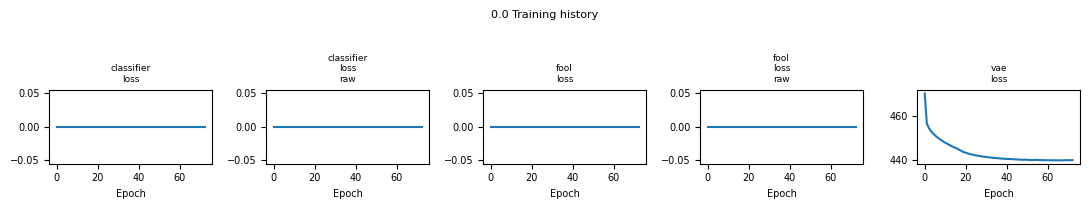

  Saved → results/disentanglement_sweep/sweep_results.h5ad

=== lambda = 1e-05 ===
INFO     Generating sequential column names                                                                        
INFO     cellina: The Cellina model has been initialized with adversarial domain forgetting                        


/data/ddimitrov/software/miniforge3/envs/cellina/lib/python3.10/site-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/data/ddimitrov/software/miniforge3/envs/cellina/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:424: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=63` in the `DataLoader` to improve performance.
/data/ddimitrov/software/miniforge3/envs/cellina/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:424: The 'val_dataloader' does not have many workers w

Training:   0%|          | 0/100 [00:00<?, ?it/s]

Monitored metric vae_loss_validation did not improve in the last 5 records. Best score: 438.717. Signaling Trainer to stop.


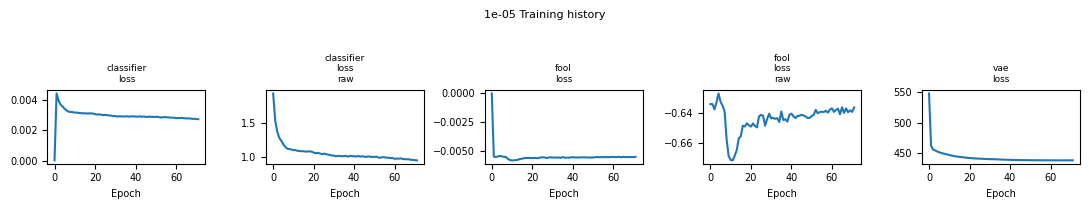

  Saved → results/disentanglement_sweep/sweep_results.h5ad

=== lambda = 1 ===
INFO     Generating sequential column names                                                                        
INFO     cellina: The Cellina model has been initialized with adversarial domain forgetting                        


/data/ddimitrov/software/miniforge3/envs/cellina/lib/python3.10/site-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/data/ddimitrov/software/miniforge3/envs/cellina/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:424: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=63` in the `DataLoader` to improve performance.
/data/ddimitrov/software/miniforge3/envs/cellina/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:424: The 'val_dataloader' does not have many workers w

Training:   0%|          | 0/100 [00:00<?, ?it/s]

Monitored metric vae_loss_validation did not improve in the last 5 records. Best score: 449.408. Signaling Trainer to stop.


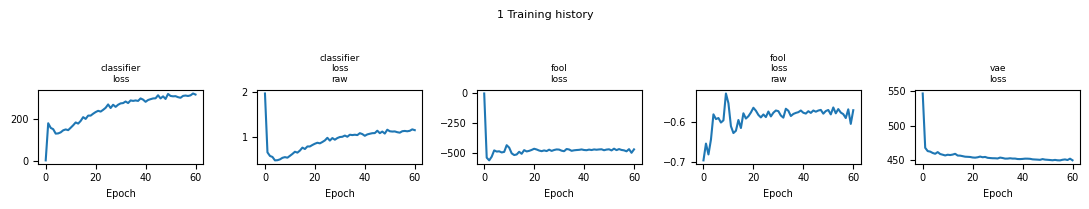

  Saved → results/disentanglement_sweep/sweep_results.h5ad

=== lambda = 50 ===
INFO     Generating sequential column names                                                                        
INFO     cellina: The Cellina model has been initialized with adversarial domain forgetting                        


/data/ddimitrov/software/miniforge3/envs/cellina/lib/python3.10/site-packages/scvi/data/fields/_layer_field.py:115: UserWarning: Training will be faster when sparse matrix is formatted as CSR. It is safe to cast before model initialization.
  _verify_and_correct_data_format(adata, self.attr_name, self.attr_key)
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/data/ddimitrov/software/miniforge3/envs/cellina/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:424: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=63` in the `DataLoader` to improve performance.
/data/ddimitrov/software/miniforge3/envs/cellina/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:424: The 'val_dataloader' does not have many workers w

Training:   0%|          | 0/100 [00:00<?, ?it/s]

Monitored metric vae_loss_validation did not improve in the last 5 records. Best score: 457.397. Signaling Trainer to stop.


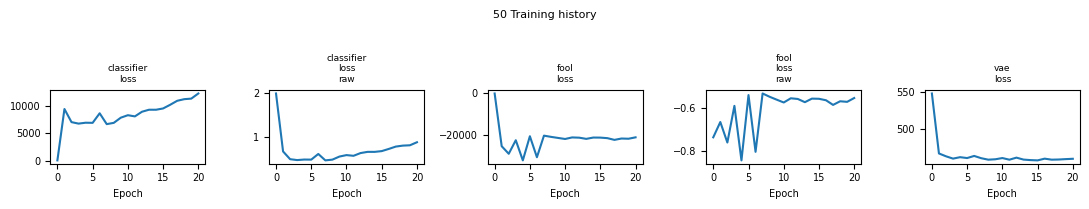

  Saved → results/disentanglement_sweep/sweep_results.h5ad


In [5]:
## 2. Sweep
for lam in lambda_values:
    print(f"\n=== lambda = {lam} ===")

    CellinaModel.setup_anndata(
        adata,
        batch_key=None,
        labels_key=labels_key,
        domains_key=domains_key,
        layer='counts',
        spatial_obsm_key='spatial_x',
    )

    model = CellinaModel(
        adata,
        n_latent=20,
        classifier_lambda=lam,
        discriminator_lambda=lam,
        n_layers=3,
        condition_on_intrinsic=False,
    )

    model.train(
        max_epochs=100,
        check_val_every_n_epoch=1,
        early_stopping=True,
        early_stopping_patience=5,
        early_stopping_monitor='vae_loss_validation',
        train_size=0.9,
        validation_size=0.1,
        plan_kwargs={'lr': 0.001, 'weight_decay': 0.0001, 'normalize_losses': True},
        enable_checkpointing=True,
        batch_size=batch_size,
        devices=[0],
    )
    

    histories = {
        'classifier_loss_validation': model.history_['classifier_loss_validation'],
        'classifier_loss_raw_validation': model.history_['classifier_loss_raw_validation'],
        'fool_loss_validation': model.history_['fool_loss_validation'],
        'fool_loss_raw_validation': model.history_['fool_loss_raw_validation'],
        'vae_loss_validation': model.history_['vae_loss_validation'],
    }

    n = len(histories)
    fig, axes = plt.subplots(1, n, figsize=(n * 2.2, 2.0))

    for ax, (key, vals) in zip(axes, histories.items()):
        ax.plot(vals)
        ax.set_title(key.replace('_validation', '').replace('_', '\n'), fontsize=6.5)
        ax.tick_params(axis='both', labelsize=7)
        ax.set_xlabel('Epoch', fontsize=7)

    fig.suptitle(f'{lam} Training history', fontsize=8, y=1.02)
    plt.tight_layout()
    plt.show()

    key = str(lam)
    adata.obsm[f'X_cellina_z_{key}'] = model.get_latent_representation(adata, latent_key='z')
    adata.obsm[f'X_cellina_s_{key}'] = model.get_latent_representation(adata, latent_key='s')

    adata.write_h5ad(adata_path)
    print(f"  Saved → {adata_path}")

## 3. Evaluation

In [6]:
adata = sc.read_h5ad(adata_path)

In [7]:
from disentanglement_eval import (
    benchmark_disentanglement, aggregate_results,
    min_max_scale_metrics, plot_results_table, WEIGHTS, _METRIC_TYPE,
)

adata_eval = sc.read_h5ad(adata_path)
# subset for faster evaluation
adata_eval = sc.pp.subsample(adata_eval, fraction=0.25, copy=True)

emb_keys = sorted([k for k in adata_eval.obsm if k.startswith('X_cellina')])
z_emb_keys = [f'X_cellina_z_{lam}' for lam in lambda_values]
s_emb_keys = [f'X_cellina_s_{lam}' for lam in lambda_values]
print(emb_keys)

['X_cellina_s_0.0', 'X_cellina_s_1', 'X_cellina_s_1e-05', 'X_cellina_s_50', 'X_cellina_z_0.0', 'X_cellina_z_1', 'X_cellina_z_1e-05', 'X_cellina_z_50']


In [8]:
print(adata_eval.shape)

(27997, 3000)


In [9]:
# z: cell type (labels_key) is the biological signal; spatial domain (domains_key) is nuisance
individual_z = benchmark_disentanglement(
    adata=adata_eval,
    embedding_obsm_keys=z_emb_keys,
    nuisance_key=domains_key,    # 'typ' — spatial domain is nuisance for z
    bio_key=labels_key,           # 'coarse_type' — label conservation for z
    batch_key=None,
    n_jobs=24,
)
results_z = aggregate_results(individual_z, **WEIGHTS)


Calculating Nuisance metrics: 100%|██████████| 4/4 [00:07<00:00,  1.80s/it]
/data/ddimitrov/software/miniforge3/envs/cellina/lib/python3.10/site-packages/scanpy/preprocessing/_pca.py:377: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  warn(msg, FutureWarning)
Embeddings: 100%|██████████| 4/4 [00:16<00:00,  4.06s/it]


In [10]:

# s: spatial domain (domains_key) is the biological signal; cell type (labels_key) is nuisance
individual_s = benchmark_disentanglement(
    adata=adata_eval,
    embedding_obsm_keys=s_emb_keys,
    nuisance_key=labels_key,     # 'coarse_type' — cell type is nuisance for s
    bio_key=domains_key,          # 'typ' — domain conservation for s
    batch_key=None,
    n_jobs=24,
)
results_s = aggregate_results(individual_s, **WEIGHTS)

Calculating Nuisance metrics:   0%|          | 0/4 [00:00<?, ?it/s]

Calculating Nuisance metrics: 100%|██████████| 4/4 [00:10<00:00,  2.56s/it]
/data/ddimitrov/software/miniforge3/envs/cellina/lib/python3.10/site-packages/scanpy/preprocessing/_pca.py:377: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  warn(msg, FutureWarning)
Embeddings: 100%|██████████| 4/4 [00:11<00:00,  2.90s/it]


Saved.


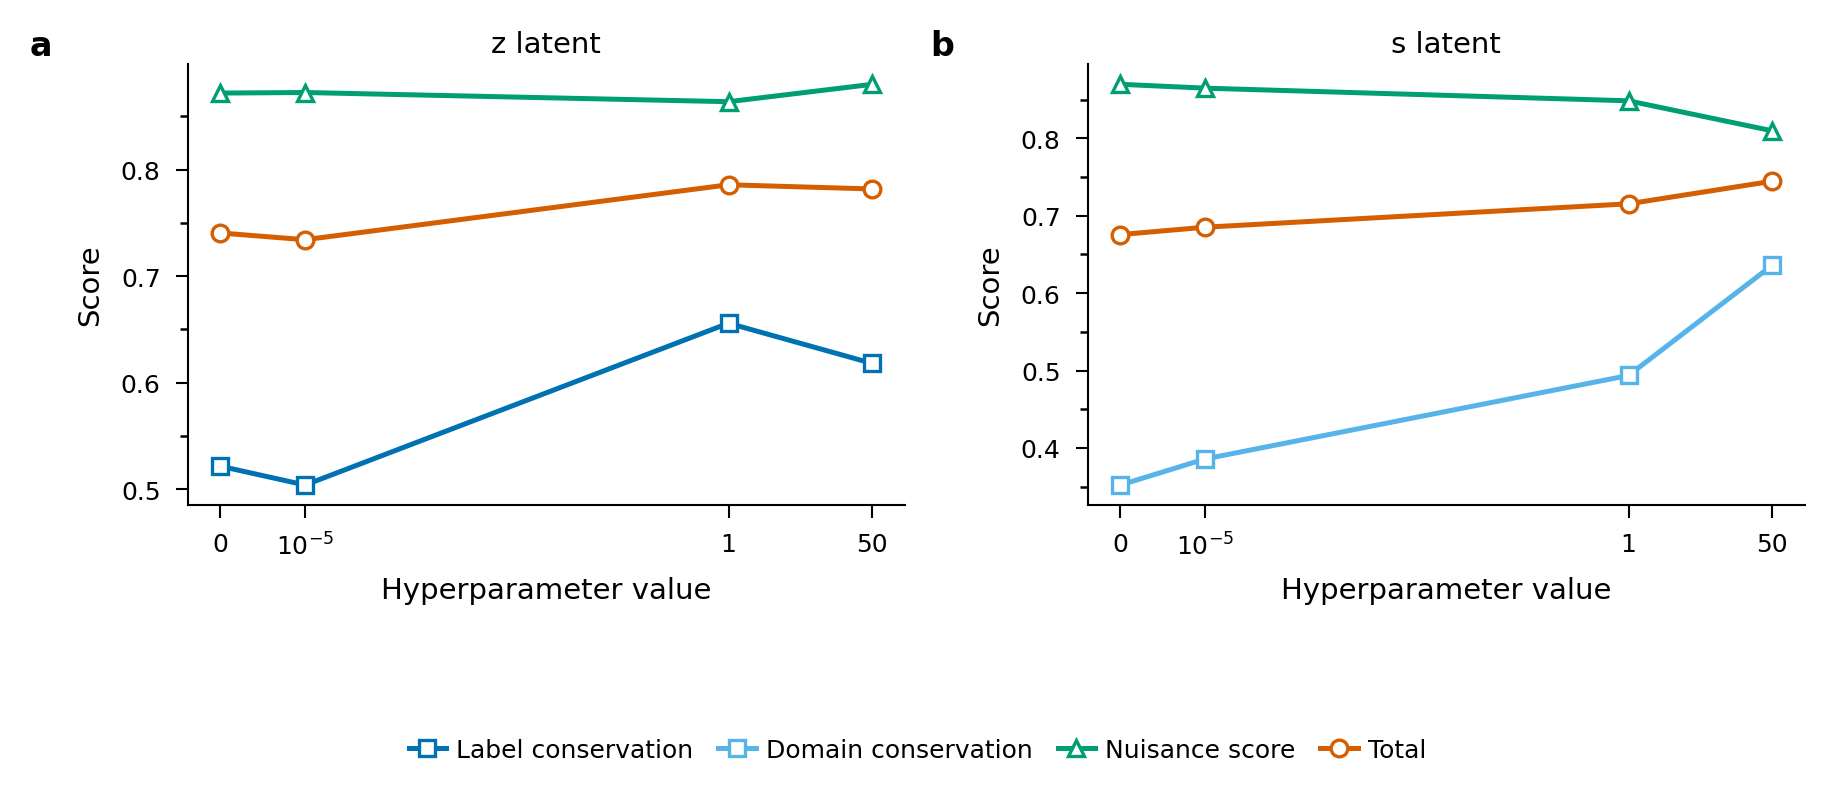

In [22]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker


matplotlib.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial", "Helvetica", "DejaVu Sans"],
    "font.size": 7,
    "axes.labelsize": 7,
    "axes.titlesize": 7,
    "xtick.labelsize": 6,
    "ytick.labelsize": 6,
    "legend.fontsize": 6,
    "axes.linewidth": 0.5,
    "xtick.major.width": 0.5,
    "ytick.major.width": 0.5,
    "xtick.major.size": 3,
    "ytick.major.size": 3,
    "xtick.minor.size": 1.5,
    "xtick.minor.width": 0.4,
    "lines.linewidth": 1.2,
    "lines.markersize": 4,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "svg.fonttype": "none",
    "figure.dpi": 300,
})

# ── Extract actual data from benchmark results ─────────────────────────────────
params = np.array(lambda_values)

def extract_metric(results_df, emb_keys, col):
    return [results_df.loc[k, col] for k in emb_keys]

data = {
    "s": {
        "Domain conservation": extract_metric(results_s, s_emb_keys, "Bio conservation"),
        "Nuisance score":      extract_metric(results_s, s_emb_keys, "Nuisance score"),
        "Total":               extract_metric(results_s, s_emb_keys, "Total"),
    },
    "z": {
        "Label conservation":  extract_metric(results_z, z_emb_keys, "Bio conservation"),
        "Nuisance score":      extract_metric(results_z, z_emb_keys, "Nuisance score"),
        "Total":               extract_metric(results_z, z_emb_keys, "Total"),
    },
}

# ── Replace 0 with a sentinel for log-scale plotting ─────────────────────────
# Must be smaller than your smallest real lambda; shown as "0" on axis
_sentinel = params[params > 0].min() / 10
params_plot = np.where(params == 0, _sentinel, params.astype(float))

# ── Color palette (Nature Methods-compatible, Okabe-Ito) ──────────────────────
_colors = {
    "Total":                "#D55E00",
    "Label conservation":   "#0072B2",
    "Domain conservation":  "#56B4E9",
    "Nuisance score":       "#009E73",
}
_markers = {
    "Total":                "o",
    "Label conservation":   "s",
    "Domain conservation":  "s",
    "Nuisance score":       "^",
}

panels = [
    ("z", "Label conservation",  "z latent", "a"),
    ("s", "Domain conservation", "s latent", "b"),
]

# ── Figure ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(
    1, 2,
    figsize=(6, 2),
    constrained_layout=True,
)

for ax, (key, bio_label, title, letter) in zip(axes, panels):

    palette = {
        bio_label:        _colors[bio_label],
        "Nuisance score": _colors["Nuisance score"],
        "Total":          _colors["Total"],
    }
    panel_markers = {
        bio_label:        _markers[bio_label],
        "Nuisance score": _markers["Nuisance score"],
        "Total":          _markers["Total"],
    }

    for metric, color in palette.items():
        ax.plot(
            params_plot,
            data[key][metric],
            color=color,
            marker=panel_markers[metric],
            markerfacecolor="white",
            markeredgecolor=color,
            markeredgewidth=0.8,
            label=metric,
            clip_on=False,
        )

    ax.set_xscale("log")
    ax.set_xlabel("Hyperparameter value")
    ax.set_title(title, pad=3)

    ax.set_xticks(params_plot)
    ax.xaxis.set_major_formatter(
        mticker.FuncFormatter(
            lambda x, _, s=_sentinel: (
                "$0$"                                          if abs(x - s) < s * 0.5
                else f"$10^{{{int(round(np.log10(x)))}}}$"    if x < 0.01
                else f"{x:g}"
            )
        )
    )
    ax.tick_params(axis="x", which="both", bottom=True)
    ax.xaxis.set_minor_locator(mticker.NullLocator())
    ax.spines[["top", "right"]].set_visible(False)

    ax.set_ylabel("Score")
    ax.yaxis.set_minor_locator(mticker.AutoMinorLocator(2))
    ax.tick_params(axis="y", which="minor", left=True)

    ax.text(
        -0.22, 1.08, letter,
        transform=ax.transAxes,
        fontsize=8, fontweight="bold", va="top",
    )

# ── Shared legend below both panels ───────────────────────────────────────────
handles_z, labels_z = axes[0].get_legend_handles_labels()
handles_s, labels_s = axes[1].get_legend_handles_labels()

legend_handles = [handles_z[0], handles_s[0], handles_z[1], handles_z[2]]
legend_labels  = [labels_z[0],  labels_s[0],  labels_z[1],  labels_z[2]]

fig.legend(
    legend_handles, legend_labels,
    loc="lower center",
    bbox_to_anchor=(0.5, -0.28),
    ncol=4,
    frameon=False,
    handlelength=1.5,
    handletextpad=0.4,
    columnspacing=1.0,
)

fig.savefig(f"{save_dir}/cellina_scores.pdf", bbox_inches="tight", dpi=300)
fig.savefig(f"{save_dir}/cellina_scores.png", bbox_inches="tight", dpi=300)
print("Saved.")

## All Metrics

In [ ]:
results = benchmark_disentanglement(
    adata=adata_eval,
    embedding_obsm_keys=z_emb_keys + s_emb_keys,
    nuisance_key=domains_key,    # 'typ' — spatial domain is nuisance for z
    bio_key=labels_key,           # 'coarse_type' — label conservation for z
    batch_key=None,
    n_jobs=24,
)

results_agg = aggregate_results(results, **WEIGHTS)

Calculating Nuisance metrics:   0%|          | 0/6 [00:00<?, ?it/s]

Calculating Nuisance metrics: 100%|██████████| 6/6 [07:16<00:00, 72.78s/it]
/data/ddimitrov/software/miniforge3/envs/cellina/lib/python3.10/site-packages/scanpy/preprocessing/_pca.py:377: FutureWarning: Argument `use_highly_variable` is deprecated, consider using the mask argument. Use_highly_variable=True can be called through mask_var="highly_variable". Use_highly_variable=False can be called through mask_var=None
  warn(msg, FutureWarning)
Embeddings: 100%|██████████| 6/6 [13:25<00:00, 134.28s/it]


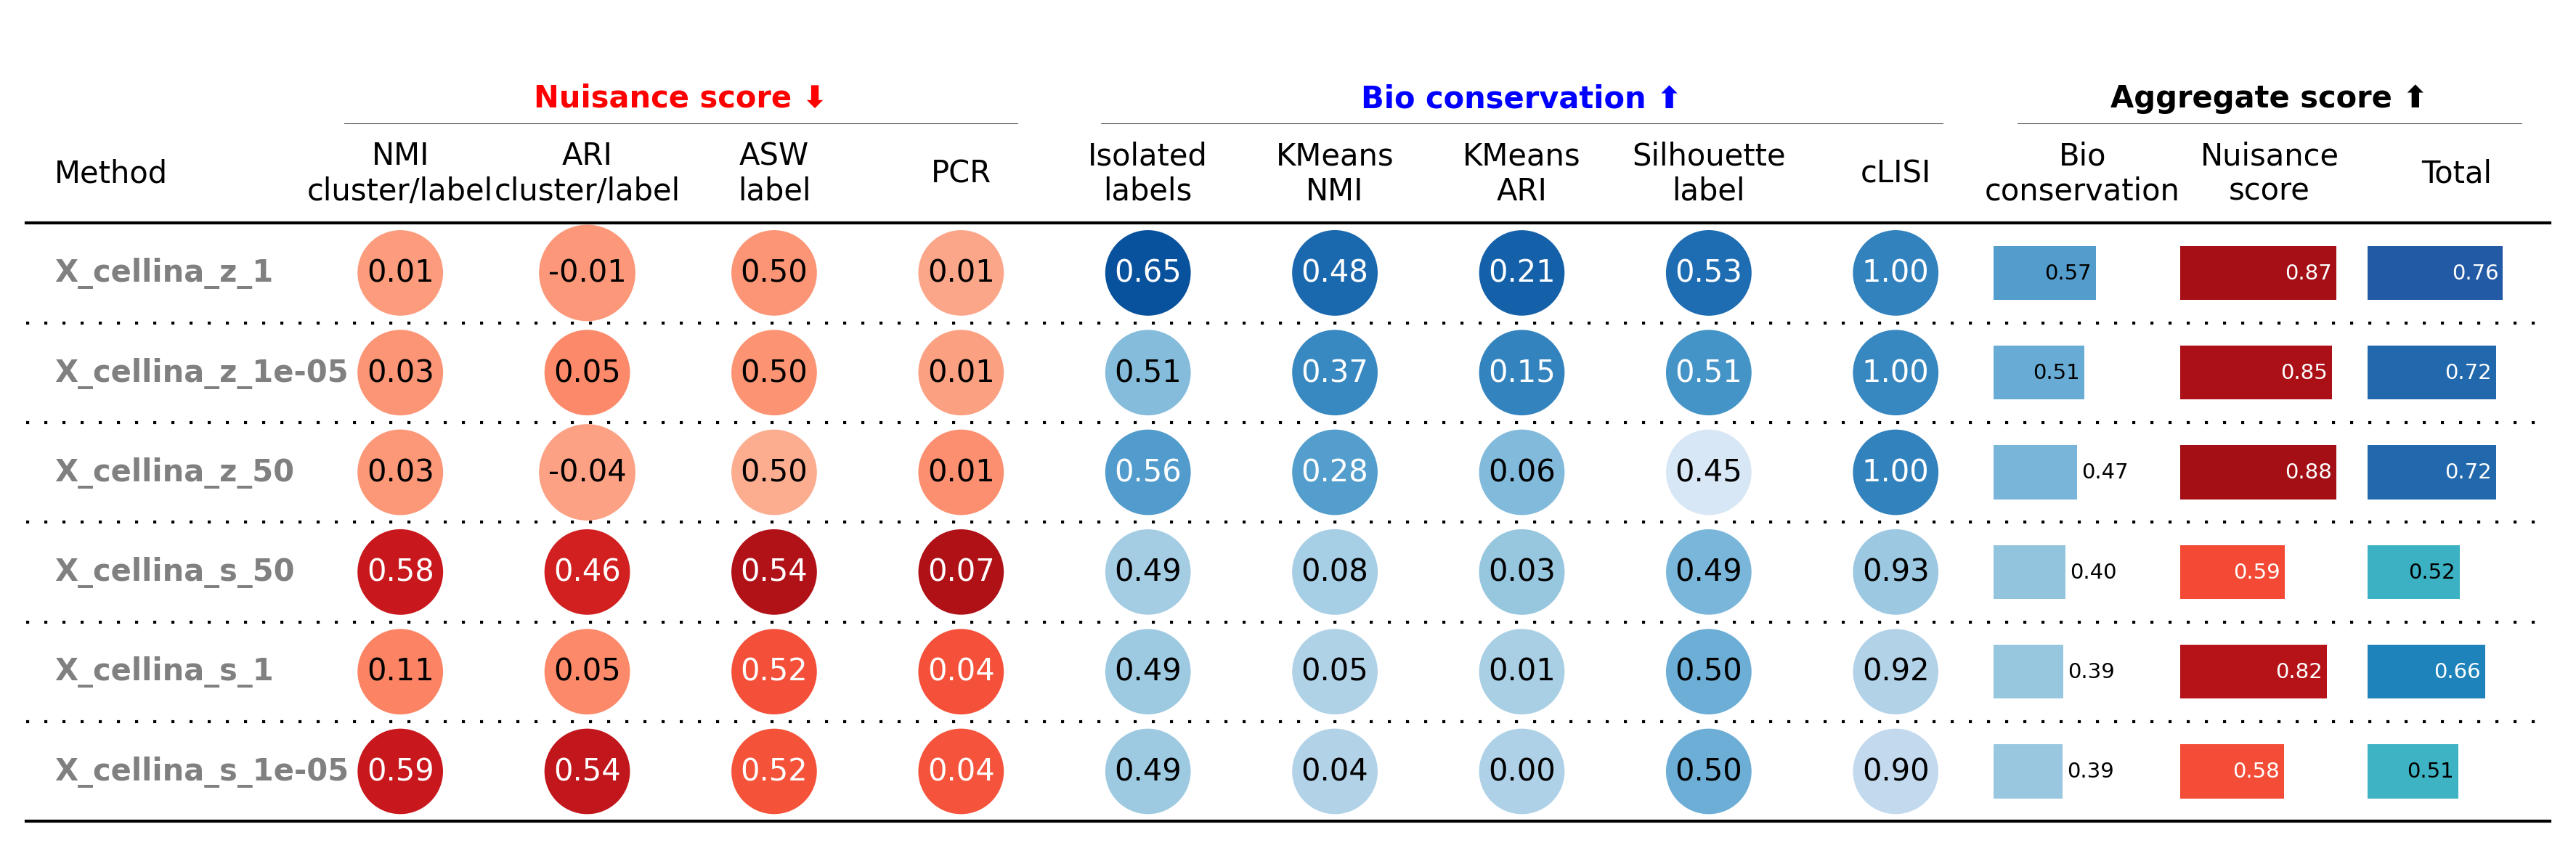

In [ ]:
plot_results_table(results_agg)